# 🕒 Delayed Lookahead Analyzer (5s Buffer)

This notebook simulates the 5-second `Delayed Buffer` approach, allowing **Non-Causal Magnetic Peak Snapping** and perfect synchronization without causal PLL guessing lag.

In [13]:
# Ensure you have librosa installed! 
import sys
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import librosa
import torch
import builtins
import torchaudio

# Add the root 'vialactee' folder to path so we can import 'core'
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..'))) 
from core.Listener import Listener

# --- CONFIGURATION ---
AUDIO_FILE = "C:/Users/Users/Desktop/vialactée/vialactee/mp3_files/01-Plastic-People.mp3" # CHANGE THIS PATH TO YOUR MP3!
TOLERANCE_WINDOW = 0.150  # Seconds. An algorithmic beat within 150ms of a true beat counts as a Hit.

print(f"Loading '{AUDIO_FILE}' globally for Ground Truth extraction...")
# Load audio using librosa for the gold standard offline beat tracking
y, sr = librosa.load(AUDIO_FILE, sr=None) 
print("Extracting actual temporal ground truth...")
tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr)
RAW_true_beats = librosa.frames_to_time(beat_frames, sr=sr)

print("Generating continuous Ground Truth phase timeline...")
bpm = tempo[0]
beat_phase = 0.0
continuous_true_beats = []
continuous_true_subbeats = []

raw_idx = 0
current_time = 0.0
dt = 1.0 / 60.0
total_time = len(y) / sr

while current_time <= total_time:
    phase_increment = (bpm / 60.0) * dt
    last_phase = beat_phase
    beat_phase += phase_increment
    
    # Soft sync to raw librosa beats to catch any drift or tempo changes
    if raw_idx < len(RAW_true_beats):
        dist = RAW_true_beats[raw_idx] - current_time
        if dist < -0.15:
            raw_idx += 1
        elif abs(dist) < 0.150:
            ideal_phase = (1.0 - (dist * bpm / 60.0)) % 1.0
            phase_diff = (ideal_phase - beat_phase + 0.5) % 1.0 - 0.5
            beat_phase += phase_diff * 0.05
            
    if last_phase < 0.5 and beat_phase >= 0.5:
        continuous_true_subbeats.append(current_time)
        
    if beat_phase >= 1.0:
        beat_phase -= 1.0
        continuous_true_beats.append(current_time)
        
    current_time += dt

true_beat_times = np.array(continuous_true_beats)
true_subbeat_times = np.array(continuous_true_subbeats)

print(f"Ground Truth established! Freewheeled {len(true_beat_times)} true beats and {len(true_subbeat_times)} true sub-beats at {bpm:.1f} BPM.")


Loading 'C:/Users/Users/Desktop/vialactée/vialactee/mp3_files/01-Plastic-People.mp3' globally for Ground Truth extraction...
Extracting actual temporal ground truth...
Generating continuous Ground Truth phase timeline...
Ground Truth established! Freewheeled 881 true beats and 882 true sub-beats at 122.3 BPM.


In [14]:
class Simulated_Microphone:
    def __init__(self, audio_file_path, bandValues, infos, chromaValues=None):
        self.bandValues = bandValues
        self.chromaValues = chromaValues
        self.nb_of_fft_band = len(self.bandValues)
        
        self.sample_rate = 44100
        self.buffer_size = 1024 
        self.audio_data = np.zeros(self.buffer_size)
        
        print(f"Loading {audio_file_path} into Simulation Buffer...")
        waveform, sr = torchaudio.load(audio_file_path)
        
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)
            
        if sr != self.sample_rate:
            resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=self.sample_rate)
            waveform = resampler(waveform)
            
        self.full_audio = waveform.numpy().flatten()
        self.total_samples = len(self.full_audio)
        self.current_pos = 0
        
        fft_size = self.buffer_size // 2 + 1
        self.weight_matrix = np.zeros((self.nb_of_fft_band, fft_size))
        
        def hz_to_mel(f): return 2595 * np.log10(1 + f / 700.0)
        def mel_to_hz(m): return 700 * (10**(m / 2595.0) - 1)
        
        lower_mel = hz_to_mel(20)
        upper_mel = hz_to_mel(20000)
        mel_points = np.linspace(lower_mel, upper_mel, self.nb_of_fft_band + 2)
        hz_points = mel_to_hz(mel_points)
        bin_points = np.floor((self.buffer_size + 1) * hz_points / self.sample_rate).astype(int)
        
        for i in range(self.nb_of_fft_band):
            start = min(bin_points[i], fft_size - 1)
            mid = min(bin_points[i + 1], fft_size - 1)
            end = min(bin_points[i + 2], fft_size - 1)
            if mid > start:
                self.weight_matrix[i, start:mid] = np.linspace(0, 1, mid - start, endpoint=False)
            if end > mid:
                self.weight_matrix[i, mid:end] = np.linspace(1, 0, end - mid, endpoint=False)
            band_sum = np.sum(self.weight_matrix[i, :])
            if band_sum > 0:
                self.weight_matrix[i, :] /= band_sum

    def pop_chunk(self, chunk_size=1024):
        if self.current_pos + chunk_size > self.total_samples:
            return False 
        
        incoming = self.full_audio[self.current_pos : self.current_pos + chunk_size]
        self.current_pos += chunk_size
        self.audio_data = np.roll(self.audio_data, -chunk_size)
        self.audio_data[-chunk_size:] = incoming
        return True

    def calculate_fft(self):
        windowed_data = self.audio_data * np.hanning(self.buffer_size)
        fft_result = np.abs(np.fft.rfft(windowed_data))
        
        scale = 150.0 / (self.buffer_size / 1024.0)
        mel_bands = np.dot(self.weight_matrix, fft_result) * scale
        
        for i in range(self.nb_of_fft_band):
            self.bandValues[i] = int(mel_bands[i])


In [15]:
from collections import deque

lookahead_frames = int(5.0 * SIMULATED_FPS)
future_queue = deque()

algorithmic_beats = []
algorithmic_sub_beats = []

history_time = []
history_bpm = []
history_binary_trust = []
history_bpm_trust = []
history_bass_flux = []

print("🚀 Starting Lookahead Analysis (5s Buffer)...")
start_real_world_time = time.time()
CHUNK_SIZE_FOR_60FPS = int(44100 / 60.0)

last_logged_beat_count = getattr(listener, 'beat_count', 0)
last_logged_beat_phase = getattr(listener, 'beat_phase', 0.0)
frame = 0

audio_time = 0.0
playhead_time = 0.0

while mic.pop_chunk(CHUNK_SIZE_FOR_60FPS):
    mic.calculate_fft()
    listener.update()
    
    is_beat = False
    is_sub_beat = False
    
    current_beat_count = getattr(listener, 'beat_count', 0)
    if current_beat_count > last_logged_beat_count:
        is_beat = True
        last_logged_beat_count = current_beat_count
        
    current_phase = getattr(listener, 'beat_phase', 0.0)
    if last_logged_beat_phase < 0.5 and current_phase >= 0.5:
        is_sub_beat = True
    last_logged_beat_phase = current_phase
    
    # Store the causal output into the future_queue (we are 5 seconds ahead of output)
    future_queue.append({
        'time': audio_time,
        'bpm': listener.bpm,
        'binary_trust': getattr(listener, 'binary_trust', 0.0),
        'bpm_trust': getattr(listener, 'bpm_trust', 0.0),
        'bass_flux': listener.band_flux[0] + listener.band_flux[1],
        'is_beat': is_beat,
        'is_sub_beat': is_sub_beat,
        'band_peak': listener.band_peak.copy()
    })
    
    # The output playhead pops the oldest frame when the buffer has 5 seconds of footage
    if len(future_queue) >= lookahead_frames:
        window = 9 # +/- 150ms 
        target = window
        
        # --- SYMMETRIC LOOKAHEAD PEAK SNAPPING (MAIN BEATS) ---
        if future_queue[target].get('is_beat', False) and not future_queue[target].get('main_snapped', False):
            best_dist = 999
            best_idx = -1
            
            # Scan +/- window around the target
            for i in range(0, 2 * window + 1):
                f = future_queue[i]
                has_bass_peak = f['band_peak'][0] > 0 or f['band_peak'][1] > 0
                if has_bass_peak:
                    dist = abs(i - target)
                    if dist < best_dist:
                        best_dist = dist
                        best_idx = i
                        
            if best_idx != -1:
                future_queue[target]['is_beat'] = False
                future_queue[best_idx]['is_beat'] = True
                future_queue[best_idx]['main_snapped'] = True
            else:
                future_queue[target]['main_snapped'] = True

        # --- SYMMETRIC LOOKAHEAD PEAK SNAPPING (SUB-BEATS) ---
        if future_queue[target].get('is_sub_beat', False) and not future_queue[target].get('sub_snapped', False):
            best_dist = 999
            best_idx = -1
            
            # Scan +/- window around the target
            for i in range(0, 2 * window + 1):
                f = future_queue[i]
                # Subbeats can snap to mid/high transients too
                has_peak = any(val > 0 for val in f['band_peak'])
                if has_peak:
                    dist = abs(i - target)
                    if dist < best_dist:
                        best_dist = dist
                        best_idx = i
                        
            if best_idx != -1:
                future_queue[target]['is_sub_beat'] = False
                future_queue[best_idx]['is_sub_beat'] = True
                future_queue[best_idx]['sub_snapped'] = True
            else:
                future_queue[target]['sub_snapped'] = True

        # Safe to pop now, as the frame at index 0 was evaluated 9 frames ago!
        present = future_queue.popleft()
        
        if present.get('is_beat', False):
            algorithmic_beats.append(playhead_time)
            
        if present.get('is_sub_beat', False):
            algorithmic_sub_beats.append(playhead_time)
            
        history_time.append(playhead_time)
        history_bpm.append(present['bpm'])
        history_binary_trust.append(present['binary_trust'])
        history_bpm_trust.append(present['bpm_trust'])
        history_bass_flux.append(present['bass_flux'])
        
        playhead_time += TIME_PER_FRAME
        
    audio_time += TIME_PER_FRAME
    frame += 1
    
    if frame % 1800 == 0:
        print(f"Processed audio time {audio_time:.1f}s...")

ListenerModule.time.time = time.time # Restore time

# Empty the remaining queue to finish the song
while future_queue:
    present = future_queue.popleft()
    if present.get('is_beat', False):
        algorithmic_beats.append(playhead_time)
    if present.get('is_sub_beat', False):
        algorithmic_sub_beats.append(playhead_time)
        
    history_time.append(playhead_time)
    history_bpm.append(present['bpm'])
    history_binary_trust.append(present['binary_trust'])
    history_bpm_trust.append(present['bpm_trust'])
    history_bass_flux.append(present['bass_flux'])
    playhead_time += TIME_PER_FRAME

alg_beats_array = np.array(algorithmic_beats)
alg_sub_beats_array = np.array(algorithmic_sub_beats)
print(f"✅ Finished! Extracted {len(alg_beats_array)} Lookahead algorithmic beats and {len(alg_sub_beats_array)} sub-beats.")


Loading C:/Users/Users/Desktop/vialactée/vialactee/mp3_files/01-Plastic-People.mp3 into Simulation Buffer...
🚀 Starting Fast-Forward Live Analysis...
Proccessed 30.0s...
Proccessed 60.0s...
Proccessed 90.0s...
Proccessed 120.0s...
Proccessed 150.0s...
Proccessed 180.0s...
Proccessed 210.0s...
Proccessed 240.0s...
Proccessed 270.0s...
Proccessed 300.0s...
Proccessed 330.0s...
Proccessed 360.0s...
Proccessed 390.0s...
Proccessed 420.0s...
✅ Finished! Extracted 880 algorithmic beats and 912 algorithmic sub-beats.


In [16]:
# EVALUATING ALGORITHMIC PERFORMANCE VS GROUND TRUTH
def evaluate_single_stream(alg_stream, true_stream, tolerance=0.150):
    matched_true = set()
    matched_alg = set()
    
    for i, a_beat in enumerate(alg_stream):
        closest_dist = float('inf')
        closest_j = -1
        for j, t_beat in enumerate(true_stream):
            if j in matched_true: continue
            dist = abs(a_beat - t_beat)
            if dist < closest_dist and dist <= tolerance:
                closest_dist = dist
                closest_j = j
                
        if closest_j != -1:
            matched_true.add(closest_j)
            matched_alg.add(i)
            
    hits = len(matched_alg)
    false_positives = len(alg_stream) - hits
    false_negatives = len(true_stream) - hits
    
    precision = hits / len(alg_stream) if len(alg_stream) > 0 else 0
    recall = hits / len(true_stream) if len(true_stream) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return hits, false_positives, false_negatives, precision, recall, f1_score, matched_alg, matched_true

m_hits, m_wrongs, m_misses, m_precision, m_recall, m_f1, m_alg_main, m_true = evaluate_single_stream(alg_beats_array, true_beat_times, TOLERANCE_WINDOW)
s_hits, s_wrongs, s_misses, s_precision, s_recall, s_f1, m_alg_sub, m_true_sub = evaluate_single_stream(alg_sub_beats_array, true_subbeat_times, TOLERANCE_WINDOW)

total_hits = m_hits + s_hits
total_wrongs = m_wrongs + s_wrongs
total_misses = m_misses + s_misses
total_alg = len(alg_beats_array) + len(alg_sub_beats_array)
total_true = len(true_beat_times) + len(true_subbeat_times)

tot_precision = total_hits / total_alg if total_alg > 0 else 0
tot_recall = total_hits / total_true if total_true > 0 else 0
tot_f1 = 2 * (tot_precision * tot_recall) / (tot_precision + tot_recall) if (tot_precision + tot_recall) > 0 else 0

print("============ 📈 EVALUATION REPORT ============")
print(f"Tolerance Window: +/- {int(TOLERANCE_WINDOW*1000)}ms")
print(f"Total True Beats: {len(true_beat_times)} | Total Sub-beats: {len(true_subbeat_times)}")
print(f"Total Algorithmic Beats: {len(alg_beats_array)} | Total Algorithmic Sub-beats: {len(alg_sub_beats_array)}")
print("----------------------------------------------")
print(f"✅ RIGHT (Main Beats): {m_hits} perfectly synced.")
print(f"☑️ RIGHT (Sub-Beats): {s_hits} perfectly synced.")
print(f"❌ WRONG (False Positives): {total_wrongs} extra/ghost commands.")
print(f"👻 MISSED (True commands): {total_misses} true beats slipped through.")
print("----------------------------------------------")
print(f"🎯 Precision: {tot_precision*100:.1f}%")
print(f"🏅 Recall: {tot_recall*100:.1f}%")
print(f"🏆 F1-SCORE (Overall Sync Quality): {tot_f1*100:.1f}%")
print("==============================================")


============ 📈 EVALUATION REPORT ============
Tolerance Window: +/- 150ms
Total True Beats: 881 | Total Sub-beats: 882
Total Algorithmic Beats: 880 | Total Algorithmic Sub-beats: 912
----------------------------------------------
✅ RIGHT (Main Beats): 560 perfectly synced.
☑️ RIGHT (Sub-Beats): 557 perfectly synced.
❌ WRONG (False Positives): 675 extra/ghost commands.
👻 MISSED (True commands): 646 true beats slipped through.
----------------------------------------------
🎯 Precision: 62.3%
🏅 Recall: 63.4%
🏆 F1-SCORE (Overall Sync Quality): 62.8%


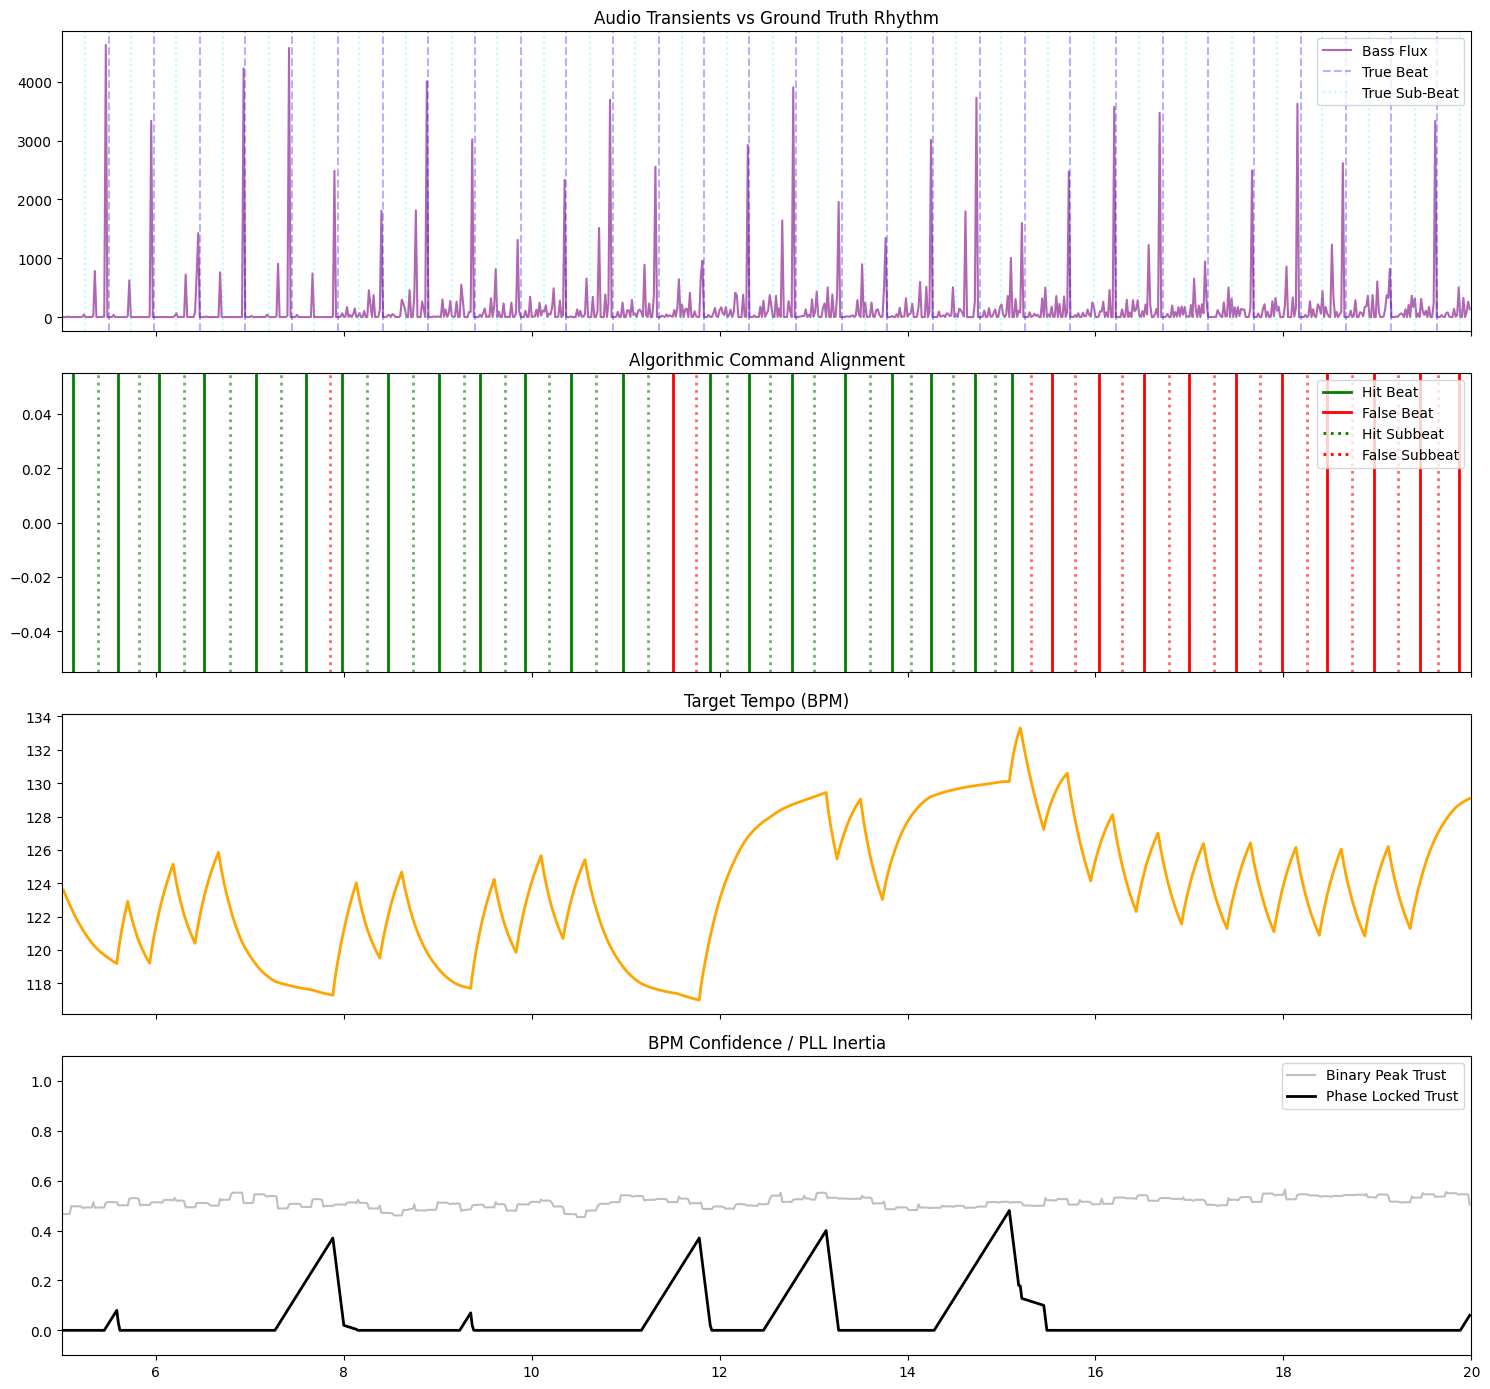

In [17]:
# Ploting Everything!
time_arr = np.array(history_time)
bpm_arr = np.array(history_bpm)
b_trust_arr = np.array(history_binary_trust)
bpm_trust_arr = np.array(history_bpm_trust)
bass_flux_arr = np.array(history_bass_flux)

fig, axs = plt.subplots(4, 1, figsize=(15, 14), sharex=True)

time_slice = (5.0, 20.0)
slice_mask = (time_arr >= time_slice[0]) & (time_arr <= time_slice[1])
slice_times = time_arr[slice_mask]

# 1. Plot Bass Flux & Ground Truth Beats
axs[0].plot(slice_times, bass_flux_arr[slice_mask], label="Bass Flux", color="purple", alpha=0.6)
for tb in true_beat_times:
    if time_slice[0] <= tb <= time_slice[1]:
        axs[0].axvline(tb, color='blue', linestyle='--', alpha=0.3)
for sb in true_subbeat_times:
    if time_slice[0] <= sb <= time_slice[1]:
        axs[0].axvline(sb, color='cyan', linestyle=':', alpha=0.3)
# The first ones to hit the label requirement
axs[0].axvline(-1, color='blue', linestyle='--', alpha=0.3, label="True Beat")
axs[0].axvline(-1, color='cyan', linestyle=':', alpha=0.3, label="True Sub-Beat")
axs[0].set_title("Audio Transients vs Ground Truth Rhythm")
axs[0].legend(loc="upper right")

# 2. Algorithmic Tracker Output
axs[1].plot(slice_times, bass_flux_arr[slice_mask] * 0, alpha=0)

correct_beats = [alg_beats_array[i] for i in m_alg_main]
false_beats = [alg_beats_array[i] for i in range(len(alg_beats_array)) if i not in m_alg_main]
correct_subbeats = [alg_sub_beats_array[i] for i in m_alg_sub]
false_subbeats = [alg_sub_beats_array[i] for i in range(len(alg_sub_beats_array)) if i not in m_alg_sub]

for b in correct_beats:
    if time_slice[0] <= b <= time_slice[1]:
        axs[1].axvline(b, color='green', linestyle='-', linewidth=2)
for b in false_beats:
    if time_slice[0] <= b <= time_slice[1]:
        axs[1].axvline(b, color='red', linestyle='-', linewidth=2)
for b in correct_subbeats:
    if time_slice[0] <= b <= time_slice[1]:
        axs[1].axvline(b, color='green', linestyle=':', linewidth=2, alpha=0.6)
for b in false_subbeats:
    if time_slice[0] <= b <= time_slice[1]:
        axs[1].axvline(b, color='red', linestyle=':', linewidth=2, alpha=0.6)

# Mock limits for legend
axs[1].axvline(-1, color='green', linestyle='-', linewidth=2, label="Hit Beat")
axs[1].axvline(-1, color='red', linestyle='-', linewidth=2, label="False Beat")
axs[1].axvline(-1, color='green', linestyle=':', linewidth=2, label="Hit Subbeat")
axs[1].axvline(-1, color='red', linestyle=':', linewidth=2, label="False Subbeat")
axs[1].set_title("Algorithmic Command Alignment")
axs[1].legend(loc="upper right")

# 3. BPM Tracking
axs[2].plot(slice_times, bpm_arr[slice_mask], color="orange", linewidth=2)
axs[2].set_title("Target Tempo (BPM)")

# 4. Trust 
axs[3].plot(slice_times, b_trust_arr[slice_mask], label="Binary Peak Trust", color="gray", alpha=0.5)
axs[3].plot(slice_times, bpm_trust_arr[slice_mask], label="Phase Locked Trust", color="black", linewidth=2)
axs[3].set_title("BPM Confidence / PLL Inertia")
axs[3].set_ylim(-0.1, 1.1)
axs[3].legend(loc="upper right")

plt.xlim(time_slice)
plt.tight_layout()
plt.show()
